In [1]:
import os
import os.path as op
import numpy as np

import matplotlib.pyplot as plt
import pickle
from scipy import stats, signal
import scipy
from scipy.interpolate import RectBivariateSpline

#import pandas as pd
from hnn_core.hnn_io import write_network_configuration, read_network_configuration
from hnn_core.dipole import average_dipoles
from hnn_core.dipole import _rmse, average_dipoles
from hnn_core.extracellular import _get_laminar_z_coords

from hnn_core import duecker_ET_model, simulate_dipole, read_dipole, MPIBackend, jones_2009_model

import sys

net = duecker_ET_model() 
net.set_cell_positions(inplane_distance=30.) # 30 microns between cells in the same layer, 30 microns between layers. Check if this is correct.
depths = list(list(range(-125,2150,100)))
electrode_pos = [(135, 135, dep) for dep in depths]
net.add_electrode_array('probe1', electrode_pos) # prob1 instead of shank1 in last Katharina's version. Check if this is correct.


In [2]:
# PLOT ONLY NHP DATA (NEW VISUALIZATION VERSION)

from pathlib import Path
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from matplotlib.ticker import MultipleLocator
from hnn_core.extracellular import _get_laminar_z_coords

# ---------------------------------------------------
# Path to data
# ---------------------------------------------------
data_path = Path.home() / "Downloads" / "imported"

# ---------------------------------------------------
# Files you want to process
# ---------------------------------------------------
files_to_plot = [
#    "1-pb0304010@e@os_lfp.mat",
#    "2-pb3738017@e@os_lfp.mat",
#    "2-pb3738015@e@os_lfp.mat",  
]

# ---------------------------------------------------
# Manual flip dictionary
# ---------------------------------------------------
flip_dict = {
#    "1-pb0304010@e@os_lfp.mat": 0,
#    "2-pb3738017@e@os_lfp.mat": 1,
    "2-pb3738015@e@os_lfp.mat": 1,
}

align_stim_dict = {
#    "1-pb0304010@e@os_lfp.mat": 1, # tap to all fingers
#    "2-pb3738017@e@os_lfp.mat": 1, # tap to all fingers
    "2-pb3738015@e@os_lfp.mat": 0, # median nerve stimulation
}

'''
def plot_stacked_traces(ax, t, data, depths, color="k", lw=0.8, alpha=1.0,
                        scale=0.3, baseline_samps=100, labels=None):
    """
    Plot each row of `data` (n_depth x n_time) as a trace offset at y=depths[i].
    `scale` is in units of median depth spacing (so it looks consistent).
    """
    depths = np.asarray(depths).astype(float)
    data = np.asarray(data)

    dz = float(np.median(np.diff(depths))) if len(depths) > 1 else 1.0
    amp = scale * dz

    for i, (z, tr) in enumerate(zip(depths, data)):
        tr0 = tr - np.mean(tr[:baseline_samps])
        trn = tr0 / (np.max(np.abs(tr0)) + 1e-12)  # normalize for display
        lab = labels[i] if labels is not None else None
        ax.plot(t, z - amp * trn, color=color, lw=lw, alpha=alpha, label=lab)
    '''
def plot_stacked_traces(ax, t, data, depths, color="k", lw=0.8, alpha=1.0,
                        scale=1.0, baseline_samps=100, labels=None):
    depths = np.asarray(depths).astype(float)
    data = np.asarray(data)

    for i, (z, tr) in enumerate(zip(depths, data)):
        tr0 = tr - np.mean(tr[:baseline_samps])   # baseline correction only
        lab = labels[i] if labels is not None else None
        ax.plot(t, z - scale * tr0, color=color, lw=lw, alpha=alpha, label=lab)

# ---------------------------------------------------
# Loop over selected files
# ---------------------------------------------------
#for fname in files_to_plot:

#file = data_path / "1-pb0304010@e@os_lfp.mat"
#file = data_path / "2-pb3738017@e@os_lfp.mat"
file = data_path / "2-pb3738015@e@os_lfp.mat"


print(f"\nProcessing {file.name}")

nhp_lfp = scipy.io.loadmat(file)



Processing 2-pb3738015@e@os_lfp.mat


In [3]:


lfp = nhp_lfp['lfp']
csd = nhp_lfp['csd']
timevec = nhp_lfp['timevec'].reshape(-1,)

# -----------------------------------------
# Manual orientation control
# -----------------------------------------
flip_flag = flip_dict.get(file.name, None)

if flip_flag is None:
    print("File not found in flip_dict — no flip applied")
elif flip_flag == 1:
    print("Flipping orientation")
    lfp = lfp[::-1] # only change depth ordering, not signal polarity
    csd = csd[::-1]
else:
    print("Orientation kept")

    


Flipping orientation


In [4]:

# -----------------------------------------
# Get laminar positions
# -----------------------------------------
contact_labels, _ = _get_laminar_z_coords(
    net.rec_arrays['probe1'].positions
)

print(contact_labels)

#depths_lfp = contact_labels
#depths_csd = contact_labels[1:-1]
#depths_lfp = contact_labels[::-1]
#depths_csd = contact_labels[1:-1][::-1]
#print(depths_lfp)
#print(depths_csd)



[-125  -25   75  175  275  375  475  575  675  775  875  975 1075 1175
 1275 1375 1475 1575 1675 1775 1875 1975 2075]


In [5]:
shape_lfp = lfp.shape
print(shape_lfp)

print(len(contact_labels))

print(contact_labels)

#print(timevec)

(23, 1000)
23
[-125  -25   75  175  275  375  475  575  675  775  875  975 1075 1175
 1275 1375 1475 1575 1675 1775 1875 1975 2075]


In [6]:
def plot_laminar_lfp_AC(
    times,
    data,
    contact_labels,
    tmin=None,
    tmax=None,
    ax=None,
    decim=None,
    color="cividis",
    voltage_offset=50,
    voltage_scalebar=200,
    show=True,
):
    """Plot laminar extracellular electrode array voltage time series.

    Parameters
    ----------
    times : array-like, shape (n_times,)
        Sampling times (in ms).
    data : Two-dimensional Numpy array
        The extracellular voltages as an (n_contacts, n_times) array.
    ax : instance of matplotlib figure | None
        The matplotlib axis
    decim : int | list of int | None (default)
        Optional (integer) factor by which to decimate the raw dipole traces.
        The SciPy function :func:`~scipy.signal.decimate` is used, which
        recommends values <13. To achieve higher decimation factors, a list of
        ints can be provided. These are applied successively.
    color : str | array of floats | ``matplotlib.colors.ListedColormap``
        The colormap to use for plotting. The usual Matplotlib standard
        colormap strings may be used (e.g., 'jetblue'). A color can also be
        defined as an RGBA-quadruplet, or an array of RGBA-values (one for each
        electrode contact trace to plot). An instance of
        :class:`~matplotlib.colors.ListedColormap` may also be provided.
    voltage_offset : float | None (optional)
        Amount to offset traces by on the voltage-axis. Useful for plotting
        laminar arrays.
    voltage_scalebar : float | None (optional)
        Height, in units of uV, of a scale bar to plot in the top-left corner
        of the plot.
    contact_labels : list
        Labels associated with the contacts to plot. Passed as-is to
        :func:`~matplotlib.axes.Axes.set_yticklabels`.
    show : bool
        If True, show the figure

    Returns
    -------
    fig : instance of plt.fig
        The matplotlib figure handle into which time series were plotted.
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap

    #_validate_type(times, (list, np.ndarray), "times")
    #_validate_type(data, (list, np.ndarray), "data")
    if isinstance(times, list):
        times = np.array(times)
    if isinstance(data, list):
        data = np.array(data)
    if data.ndim != 2:
        raise ValueError(f"data must be 2D, got shape {data.shape}")
    if len(times) != data.shape[1]:
        raise ValueError(
            f"length of times ({len(times)}) and data ({len(data)}) do not match"
        )

    n_contacts = data.shape[0]
    if color is not None:
        #_validate_type(color, (str, tuple, list, np.ndarray, ListedColormap), "color")
        if isinstance(color, (tuple, list)):
            if (
                not np.all([isinstance(c, float) for c in color])
                or len(color) < 3
                or len(color) > 4
            ):
                raise ValueError(f"color must be length 3 or 4, got {color}")
        elif isinstance(color, np.ndarray):
            if color.shape[0] != n_contacts or (
                color.shape[1] < 3 or color.shape[1] > 4
            ):
                raise ValueError(f"color must be n_contacts x (3 or 4), got {color}")
        elif isinstance(color, ListedColormap):
            if color.N != n_contacts:
                raise ValueError(
                    f"ListedColormap has N={color.N}, but "
                    f"there are {n_contacts} contacts"
                )
        #elif isinstance(color, str):
        #    color = plt.get_cmap(color, len(contact_labels))
        elif isinstance(color, str):
            if color in plt.colormaps():
                color = plt.get_cmap(color, len(contact_labels))
            # else: plain color string (e.g. "black"), passed directly to ax.plot()

    if ax is None:
        _, ax = plt.subplots(1, 1)

    n_offsets = data.shape[0]
    trace_offsets = np.zeros((n_offsets, 1))
    if voltage_offset is not None:
        #trace_offsets = np.arange(n_offsets)[:, np.newaxis] * voltage_offset # voltage_offset determines how much traces are separated on the voltage axis
        # line above is the original version: only works for HNN where (probably) HNN number contacts are (contact 0 = deepest; last contact = most superficial). 
        trace_offsets = np.arange(n_offsets - 1, -1, -1)[:, np.newaxis] * voltage_offset
        contact_labels = contact_labels[::-1]
    for contact_no, trace in enumerate(np.atleast_2d(data)):
        plot_data = trace
        plot_times = times

        if decim is not None:
            plot_data, plot_times = _decimate_plot_data(decim, plot_data, plot_times)

        if isinstance(color, np.ndarray):
            col = color[contact_no]
        elif isinstance(color, ListedColormap):
            col = color(contact_no)
        else:
            col = color
        ax.plot(
            plot_times,
            plot_data + trace_offsets[contact_no],
            label=f"C{contact_no}",
            color=col,
        )

        # To be removed after deprecation cycle
        if tmin is not None or tmax is not None:
            ax.set_xlim(left=tmin, right=tmax)
            #warnings.warn(
            #    "tmin and tmax are deprecated and will be "
            #    "removed in future releases of hnn-core. Please"
            #    "use matplotlib plt.xlim to set tmin and tmax.",
            #    DeprecationWarning,
            #)

        else:
            ax.set_xlim(left=times[0], right=times[-1])
    if voltage_offset is not None:
        ax.set_ylim(-voltage_offset, n_offsets * voltage_offset)
        ylabel = "Individual contact traces"
        if len(contact_labels) != n_offsets:
            raise ValueError(
                f"contact_labels is length {len(contact_labels)},"
                f" but {n_offsets} contacts to be plotted"
            )
        else:
            trace_ticks = np.arange(
                0, len(contact_labels) * voltage_offset, voltage_offset
            )
            ax.set_yticks(trace_ticks)
            ax.set_yticklabels(contact_labels)

        if voltage_scalebar is None:
            voltage_scalebar = voltage_offset

    if voltage_scalebar is not None:
        from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

        scalebar = AnchoredSizeBar(
            ax.transData,
            1,
            f"{voltage_scalebar:.0f} " + r"$\mu V$",
            "upper left",
            size_vertical=voltage_scalebar,
            pad=0.1,
            color="black",
            label_top=False,
            frameon=False,
        )
        ax.add_artist(scalebar)
    else:
        ylabel = r"Electric potential ($\mu V$)"
        ax.ticklabel_format(axis="both", scilimits=(-2, 3))

    ax.set_ylabel(ylabel, multialignment="center")
    ax.set_xlabel("Time (ms)")

    #plt_show()
    return ax.get_figure()

In [ ]:
print(timevec)


[0.         0.0005005  0.001001   0.0015015  0.002002   0.0025025
 0.003003   0.0035035  0.004004   0.0045045  0.00500501 0.00550551
 0.00600601 0.00650651 0.00700701 0.00750751 0.00800801 0.00850851
 0.00900901 0.00950951 0.01001001 0.01051051 0.01101101 0.01151151
 0.01201201 0.01251251 0.01301301 0.01351351 0.01401401 0.01451451
 0.01501502 0.01551552 0.01601602 0.01651652 0.01701702 0.01751752
 0.01801802 0.01851852 0.01901902 0.01951952 0.02002002 0.02052052
 0.02102102 0.02152152 0.02202202 0.02252252 0.02302302 0.02352352
 0.02402402 0.02452452 0.02502503 0.02552553 0.02602603 0.02652653
 0.02702703 0.02752753 0.02802803 0.02852853 0.02902903 0.02952953
 0.03003003 0.03053053 0.03103103 0.03153153 0.03203203 0.03253253
 0.03303303 0.03353353 0.03403403 0.03453453 0.03503504 0.03553554
 0.03603604 0.03653654 0.03703704 0.03753754 0.03803804 0.03853854
 0.03903904 0.03953954 0.04004004 0.04054054 0.04104104 0.04154154
 0.04204204 0.04254254 0.04304304 0.04354354 0.04404404 0.04454

NameError: name 'stim_flag' is not defined

In [9]:
stim_flag = align_stim_dict.get(file.name, None)
print(stim_flag)

0


[-125  -25   75  175  275  375  475  575  675  775  875  975 1075 1175
 1275 1375 1475 1575 1675 1775 1875 1975 2075]


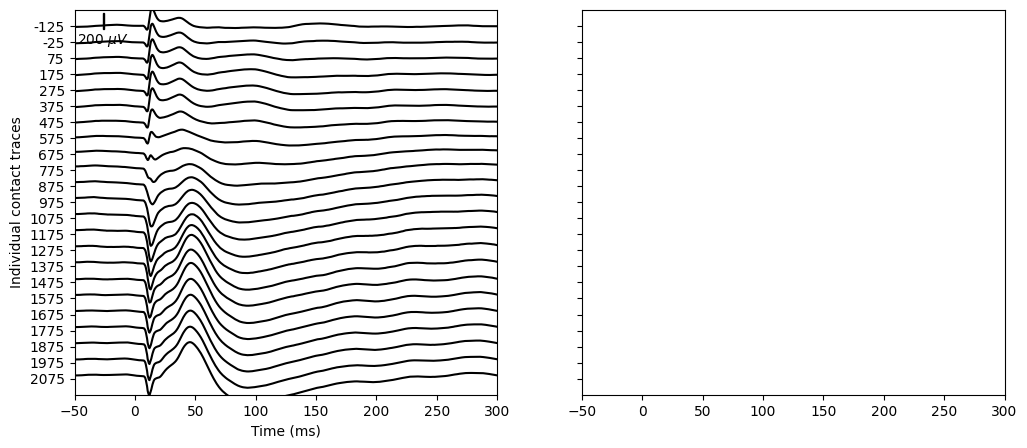

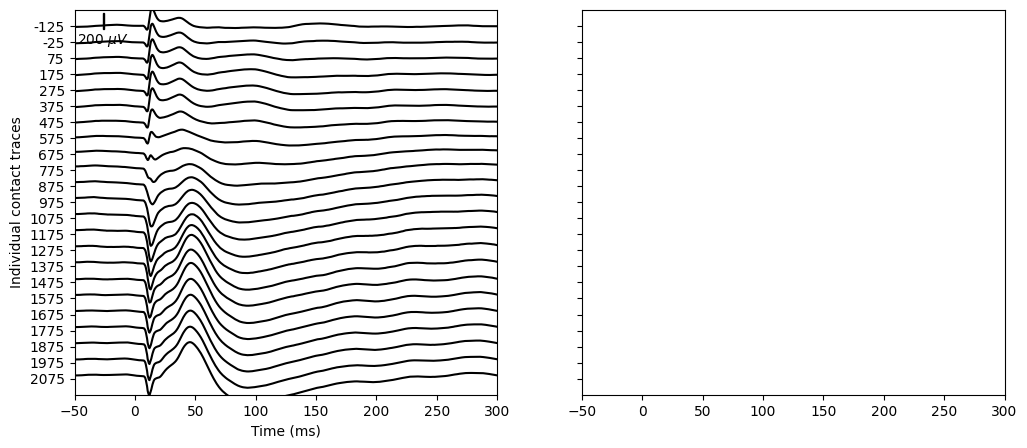

In [7]:
from hnn_core.extracellular import _get_laminar_z_coords
from hnn_core.viz import plot_laminar_lfp

stim_flag = align_stim_dict.get(file.name, None)

if stim_flag == 1:
    t = timevec * 1000 - 50 -33
else:
    t = timevec * 1000 - 50

array = net.rec_arrays['probe1']
contact_labels, _ = _get_laminar_z_coords(array.positions)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
#ax[0].clear()

print(contact_labels)

plot_laminar_lfp_AC(
    t,
    lfp,
    ax=ax[0],   # or ax[1]
    contact_labels=contact_labels,
    tmin=-50,
    tmax=300,
    voltage_offset=200,
    show=False,
    color="black"
)



In [16]:
def plot_laminar_csd_AC(
    times,
    data,
    contact_labels,
    ax=None,
    colorbar=True,
    vmin=None,
    vmax=None,
    sink="b",
    interpolation="spline",
    show=True,
):
    """Plot laminar current source density (CSD) estimation from LFP array.

    Parameters
    ----------
    times : Numpy array, shape (n_times,)
        Sampling times (in ms).
    data : array-like, shape (n_channels, n_times)
        CSD data, channels x time.
    ax : instance of matplotlib figure | None
        The matplotlib axis.
    colorbar : bool
        If True (default), adjust figure to include colorbar.
    contact_labels : list
        Labels associated with the contacts to plot. Passed as-is to
        :func:`~matplotlib.axes.Axes.set_yticklabels`.
    vmin: float, optional
        lower bound of the color axis.
        Will be set automatically of None.
    vmax: float, optional
        upper bound of the color axis.
        Will be set automatically of None.
    sink : str
        If set to 'blue' or 'b', plots sinks in blue and sources in red,
        if set to 'red' or 'r', sinks plotted in red and sources blue.
    interpolation : str | None
        If 'spline', will smoothen the CSD using spline method,
        if None, no smoothing will be applied.

    show : bool
        If True, show the plot.

    Returns
    -------
    fig : instance of matplotlib Figure
        The matplotlib figure handle.
    """
    import matplotlib.pyplot as plt
    from scipy.interpolate import RectBivariateSpline

    if ax is None:
        _, ax = plt.subplots(1, 1, constrained_layout=True)

    if sink[0].lower() == "b":
        cmap = "jet"
    elif sink[0].lower() == "r":
        cmap = "jet_r"
    elif sink[0].lower() != "b" or sink[0].lower() != "r":
        raise RuntimeError(
            'Please use sink = "b" or sink = "r".'
            ' Only colormap "jet" is supported for CSD.'
        )

    if interpolation == "spline":
        # create interpolation function
        interp_data = RectBivariateSpline(times, contact_labels, data.T)
        # increase number of contacts

        new_depths = np.linspace(
            contact_labels[0],
            contact_labels[-1],
            contact_labels[-1] - contact_labels[0],
        )
        # next few lines work fine for NHP data that do not need to be flipped (contact 0 = most superficial; last contact = deepest)
        # interpolate
        data = interp_data(times, new_depths).T
        # AC:only for experimental data:
        new_depths = new_depths[::-1]
    elif interpolation is None:
        data = data
        new_depths = contact_labels

    # if vmin and vmax are both None, set colormap such that green = zero
    if vmin is None and vmax is None:
        vmin = -np.max(np.abs(data))
        vmax = np.max(np.abs(data))

    im = ax.pcolormesh(
        times, new_depths, data, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax, rasterized=True
    )
    ax.set_xlabel("time (s)")
    ax.set_ylabel("electrode depth")
    if colorbar:
        color_axis = ax.inset_axes([1.05, 0, 0.02, 1], transform=ax.transAxes)
        plt.colorbar(im, ax=ax, cax=color_axis).set_label(r"$CSD (uV/um^{2})$")

    plt.tight_layout()
    #plt_show(show)

    return ax.get_figure()

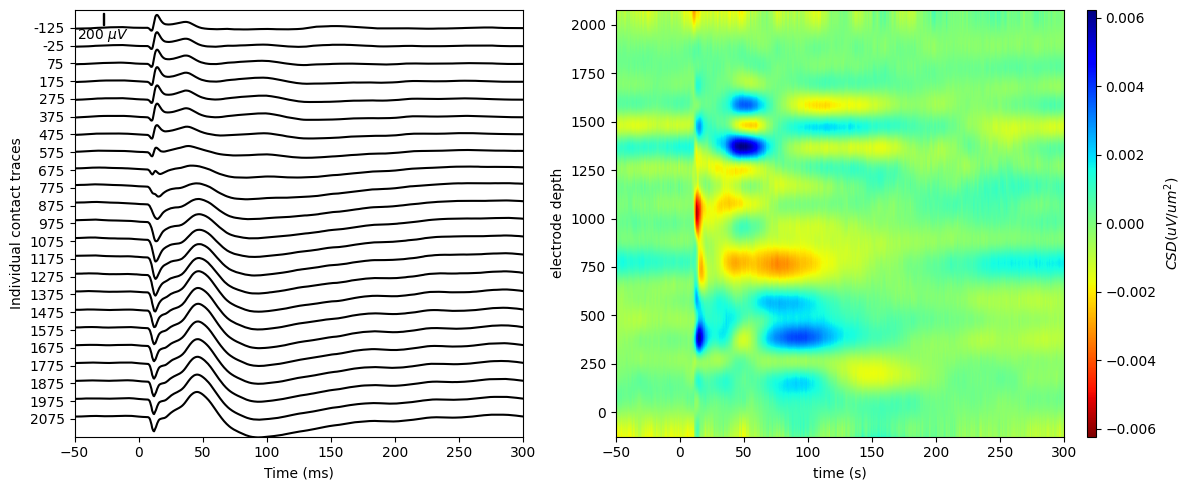

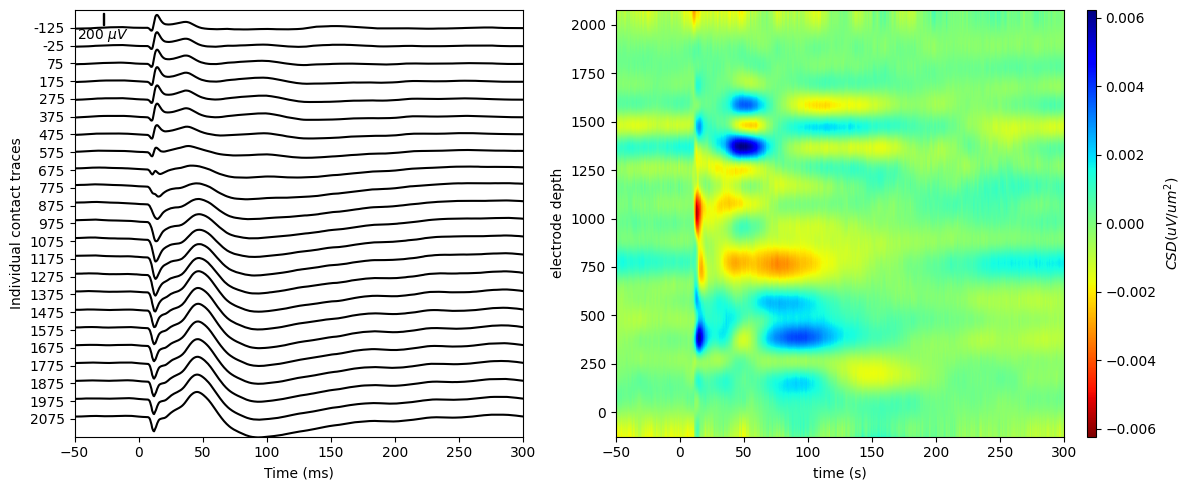

In [15]:
from hnn_core.extracellular import calculate_csd2d    

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=False)

plot_laminar_lfp_AC(
    t,
    lfp,
    ax=ax[0],
    contact_labels=contact_labels,
    tmin=-50,
    tmax=300,
    voltage_offset=300,
    show=False,
    color="black"
)
# plot HNN dipole and experimental ERP
#ax[0,0].plot(exp_dpl.times, exp_dpl.data['agg'], label='data')
#ax[0,0].plot(dpl[0].times, dpl[0].data['agg'], label='model')
#ax[0,0].legend()

#net.cell_response.plot_spikes_raster(ax=ax[0,1], show=False);

delta = float(np.median(np.diff(depths)))
csd = calculate_csd2d(lfp, delta=delta)

#ax[1].clear()
plot_laminar_csd_AC(
    t,
    csd,
    contact_labels=contact_labels,
    ax=ax[1],
    sink="r",
    interpolation="spline",
    show=True,
)

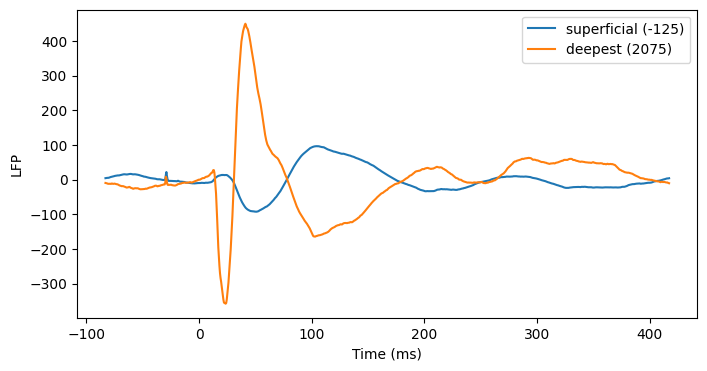

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

i_sup = 0 # most superficial contact
i_deep = -1 # deepest contact
offset = 0

ax.plot(t, lfp[i_sup] + offset, label=f"superficial ({contact_labels[i_sup]})")
ax.plot(t, lfp[i_deep], label=f"deepest ({contact_labels[i_deep]})")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("LFP")
ax.legend()
plt.show()

(-50.0, 200.0)

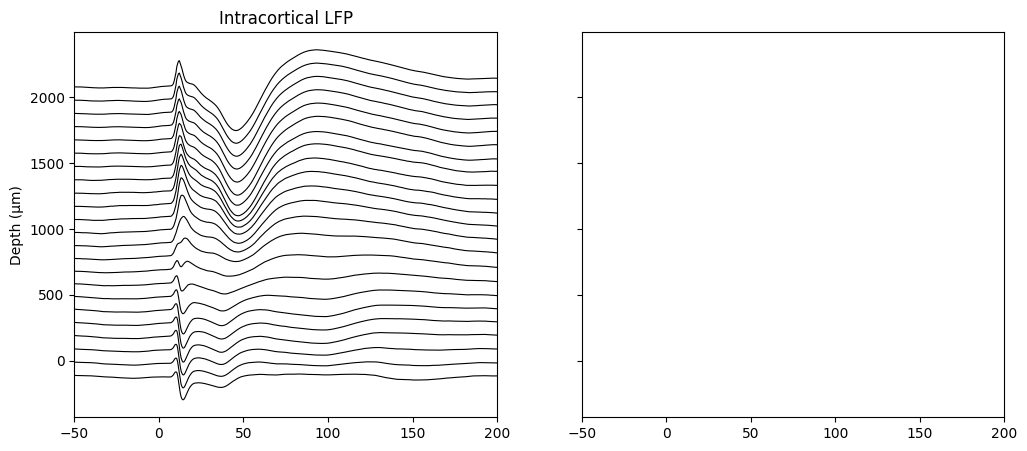

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: stacked LFP traces -----------------
# colors = plt.get_cmap('PiYG_r', lfp.shape[0])(np.linspace(0, 1, lfp.shape[0]))
plot_stacked_traces(
    ax=ax[0],
    t=t,
    data=lfp,
    depths=depths_lfp,
    color="k",
    lw=0.8,
    alpha=1.0,
    scale=0.8,#100,          # adjust if needed for better visualization
    baseline_samps=100,
)

ax[0].set_title("Intracortical LFP")
ax[0].set_ylabel("Depth (µm)")
#ax[0].invert_yaxis()
ax[0].set_xlim([-50, 200])


In [ ]:



# -----------------------------------------
# Baseline correction
# -----------------------------------------
csd = csd - np.mean(csd[:, :100], axis=1, keepdims=True)


# -----------------------------------------
# Interpolation
# -----------------------------------------
interp_data = RectBivariateSpline(
    timevec,
    contact_labels[1:-1],
    csd.T
)

new_depths = np.linspace(
    contact_labels[0],
    contact_labels[-1],
    contact_labels[-1] - contact_labels[0],
)

data_csd_interp = interp_data(timevec, new_depths).T

# Precompute time in ms
# t = timevec * 1000 - 50

stim_flag = align_stim_dict.get(file.name, None)

if stim_flag == 1:
    t = timevec * 1000 - 50 -33
else:
    t = timevec * 1000 - 50

# -----------------------------------------
# Plot
# -----------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: stacked LFP traces -----------------
# colors = plt.get_cmap('PiYG_r', lfp.shape[0])(np.linspace(0, 1, lfp.shape[0]))
plot_stacked_traces(
    ax=ax[0],
    t=t,
    data=lfp,
    depths=depths_lfp,
    color="k",
    lw=0.8,
    alpha=1.0,
    scale=0.8,#100,          # adjust if needed for better visualization
    baseline_samps=100,
)

ax[0].set_title("Intracortical LFP")
ax[0].set_ylabel("Depth (µm)")
#ax[0].invert_yaxis()
ax[0].set_xlim([-50, 200])

'''
#for d, nlfp in enumerate(lfp):
#    ax[0].plot(t, nlfp, color=colors[d])

for d, nlfp in enumerate(lfp[::-1]):
    if d == 0:
        lab = "Deep"
    elif d == lfp.shape[0] - 1:
        lab = "Superficial"
    else:
        lab = None

    ax[0].plot(t, nlfp, color=colors[::-1][d], lw=1, label=lab)

# reorder legend: superficial first, deepest second
handles, labels = ax[0].get_legend_handles_labels()
order = [labels.index("Superficial"), labels.index("Deep")]
ax[0].legend([handles[i] for i in order], [labels[i] for i in order],
            loc="upper right", frameon=False)
'''

ax[0].set_title("NHP LFP")
ax[0].set_ylabel("LFP (mV)")
ax[0].set_xlim([-50, 200])

# Right: interpolated CSD heatmap + stacked CSD traces on top

im = ax[1].pcolormesh(
    t,
    new_depths,
    data_csd_interp,
    cmap='jet_r',
    shading="auto",
    rasterized=True
)

plot_stacked_traces(
    ax=ax[1],
    t=t,
    data=csd,
    depths=depths_csd,
    color="k",
    lw=0.7,
    alpha=0.9,
    scale=1.1,
    baseline_samps=100,
)

ax[1].set_title("CSD (traces + interpolated map)")
#ax[1].invert_yaxis()
ax[1].set_xlim([-50, 200])

cbar = fig.colorbar(im, ax=ax[1])
cbar.set_label(r"$CSD (mV/mm^{2})$")

ax[1].set_title("NHP CSD")
ax[1].set_ylabel("contact depth")

ax[0].set_xlim([-50, 200])
ax[0].xaxis.set_major_locator(MultipleLocator(25))  # labels every 25 ms
ax[0].xaxis.set_minor_locator(MultipleLocator(5))   # minor ticks every 5 ms

ax[1].set_xlim([-50, 200])
ax[1].xaxis.set_major_locator(MultipleLocator(25))
ax[1].xaxis.set_minor_locator(MultipleLocator(5))

fig.suptitle(file.stem)
plt.tight_layout()

out_png = data_path / f"{file.stem}_lfp_csd_traces.png"
out_pdf = data_path / f"{file.stem}_lfp_csd_traces.pdf"  # optional
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")       # optional


plt.show()
'''
# Save CSD traces 8 and 16 only for the second dataset
if fname == "2-pb3738017@e@os_lfp.mat":
    trace8 = csd[7]    # Python index 7 = trace 8
    trace16 = csd[15]  # Python index 15 = trace 16

    data_trace8 = np.column_stack((t, trace8))
    data_trace16 = np.column_stack((t, trace16))

    np.savetxt(
        data_path / "2-pb3738017_trace8_with_time.txt",
        data_trace8,
        header="time_ms csd_trace8",
        comments=""
    )
    np.savetxt(
        data_path / "2-pb3738017_trace16_with_time.txt",
        data_trace16,
        header="time_ms csd_trace16",
        comments=""
    )
'''


Processing 2-pb3738015@e@os_lfp.mat
Flipping orientation
[-125  -25   75  175  275  375  475  575  675  775  875  975 1075 1175
 1275 1375 1475 1575 1675 1775 1875 1975 2075]
[-125  -25   75  175  275  375  475  575  675  775  875  975 1075 1175
 1275 1375 1475 1575 1675 1775 1875 1975 2075]


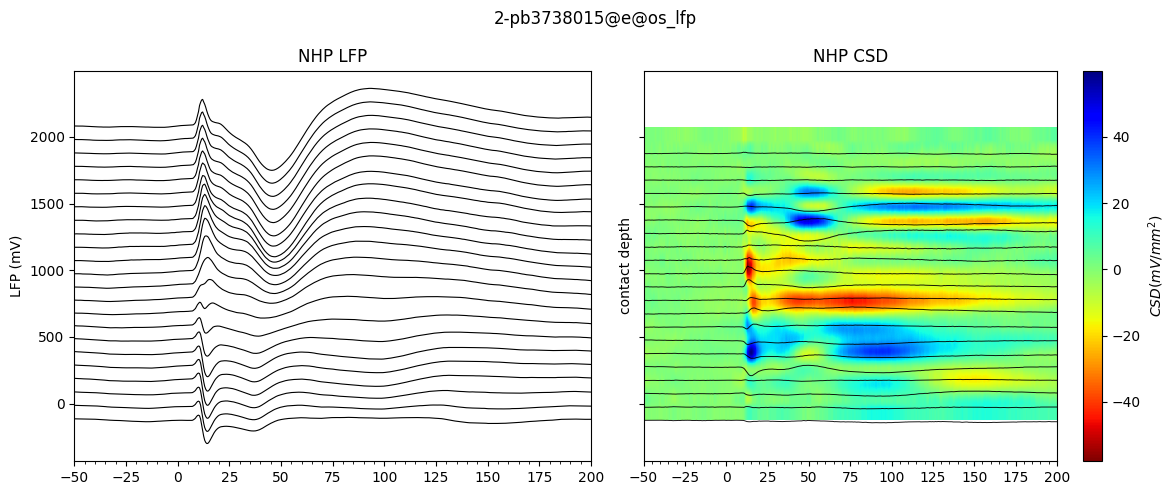

In [3]:
# PLOT ONLY NHP DATA (NEW VISUALIZATION VERSION)

from pathlib import Path
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from matplotlib.ticker import MultipleLocator
from hnn_core.extracellular import _get_laminar_z_coords

# ---------------------------------------------------
# Path to data
# ---------------------------------------------------
data_path = Path.home() / "Downloads" / "imported"

# ---------------------------------------------------
# Files you want to process
# ---------------------------------------------------
files_to_plot = [
#    "1-pb0304010@e@os_lfp.mat",
#    "2-pb3738017@e@os_lfp.mat",
    "2-pb3738015@e@os_lfp.mat",  
]

# ---------------------------------------------------
# Manual flip dictionary
# ---------------------------------------------------
flip_dict = {
#    "1-pb0304010@e@os_lfp.mat": 0,
#    "2-pb3738017@e@os_lfp.mat": 1,
    "2-pb3738015@e@os_lfp.mat": 1,
}

align_stim_dict = {
#    "1-pb0304010@e@os_lfp.mat": 1, # tap to all fingers
#    "2-pb3738017@e@os_lfp.mat": 1, # tap to all fingers
    "2-pb3738015@e@os_lfp.mat": 0, # median nerve stimulation
}

'''
def plot_stacked_traces(ax, t, data, depths, color="k", lw=0.8, alpha=1.0,
                        scale=0.3, baseline_samps=100, labels=None):
    """
    Plot each row of `data` (n_depth x n_time) as a trace offset at y=depths[i].
    `scale` is in units of median depth spacing (so it looks consistent).
    """
    depths = np.asarray(depths).astype(float)
    data = np.asarray(data)

    dz = float(np.median(np.diff(depths))) if len(depths) > 1 else 1.0
    amp = scale * dz

    for i, (z, tr) in enumerate(zip(depths, data)):
        tr0 = tr - np.mean(tr[:baseline_samps])
        trn = tr0 / (np.max(np.abs(tr0)) + 1e-12)  # normalize for display
        lab = labels[i] if labels is not None else None
        ax.plot(t, z - amp * trn, color=color, lw=lw, alpha=alpha, label=lab)
    '''
def plot_stacked_traces(ax, t, data, depths, color="k", lw=0.8, alpha=1.0,
                        scale=1.0, baseline_samps=100, labels=None):
    depths = np.asarray(depths).astype(float)
    data = np.asarray(data)

    for i, (z, tr) in enumerate(zip(depths, data)):
        tr0 = tr - np.mean(tr[:baseline_samps])   # baseline correction only
        lab = labels[i] if labels is not None else None
        ax.plot(t, z - scale * tr0, color=color, lw=lw, alpha=alpha, label=lab)

# ---------------------------------------------------
# Loop over selected files
# ---------------------------------------------------
for fname in files_to_plot:

    file = data_path / fname
    print(f"\nProcessing {file.name}")

    nhp_lfp = scipy.io.loadmat(file)

    lfp = nhp_lfp['lfp']
    csd = nhp_lfp['csd']
    timevec = nhp_lfp['timevec'].reshape(-1,)

    # -----------------------------------------
    # Manual orientation control
    # -----------------------------------------
    flip_flag = flip_dict.get(file.name, None)

    if flip_flag is None:
        print("File not found in flip_dict — no flip applied")
    elif flip_flag == 1:
        print("Flipping orientation")
        lfp = lfp[::-1] # only change depth ordering, not signal polarity
        csd = csd[::-1]
    else:
        print("Orientation kept")

    # -----------------------------------------
    # Get laminar positions
    # -----------------------------------------
    contact_labels, _ = _get_laminar_z_coords(
        net.rec_arrays['probe1'].positions
    )

    depths_lfp = contact_labels
    depths_csd = contact_labels#[1:-1]
    #depths_lfp = contact_labels[::-1]
    #depths_csd = contact_labels[1:-1][::-1]
    print(depths_lfp)
    print(depths_csd)


    # -----------------------------------------
    # Baseline correction
    # -----------------------------------------
    csd = csd - np.mean(csd[:, :100], axis=1, keepdims=True)

    
    # -----------------------------------------
    # Interpolation
    # -----------------------------------------
    interp_data = RectBivariateSpline(
        timevec,
        contact_labels[1:-1],
        csd.T
    )

    new_depths = np.linspace(
        contact_labels[0],
        contact_labels[-1],
        contact_labels[-1] - contact_labels[0],
    )

    data_csd_interp = interp_data(timevec, new_depths).T

    # Precompute time in ms
    # t = timevec * 1000 - 50

    stim_flag = align_stim_dict.get(file.name, None)

    if stim_flag == 1:
        t = timevec * 1000 - 50 -33
    else:
        t = timevec * 1000 - 50

    # -----------------------------------------
    # Plot
    # -----------------------------------------

    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # Left: stacked LFP traces -----------------
    # colors = plt.get_cmap('PiYG_r', lfp.shape[0])(np.linspace(0, 1, lfp.shape[0]))
    plot_stacked_traces(
        ax=ax[0],
        t=t,
        data=lfp,
        depths=depths_lfp,
        color="k",
        lw=0.8,
        alpha=1.0,
        scale=0.8,#100,          # adjust if needed for better visualization
        baseline_samps=100,
    )

    ax[0].set_title("Intracortical LFP")
    ax[0].set_ylabel("Depth (µm)")
    #ax[0].invert_yaxis()
    ax[0].set_xlim([-50, 200])

    '''
    #for d, nlfp in enumerate(lfp):
    #    ax[0].plot(t, nlfp, color=colors[d])

    for d, nlfp in enumerate(lfp[::-1]):
        if d == 0:
            lab = "Deep"
        elif d == lfp.shape[0] - 1:
            lab = "Superficial"
        else:
            lab = None

        ax[0].plot(t, nlfp, color=colors[::-1][d], lw=1, label=lab)

    # reorder legend: superficial first, deepest second
    handles, labels = ax[0].get_legend_handles_labels()
    order = [labels.index("Superficial"), labels.index("Deep")]
    ax[0].legend([handles[i] for i in order], [labels[i] for i in order],
                loc="upper right", frameon=False)
    '''

    ax[0].set_title("NHP LFP")
    ax[0].set_ylabel("LFP (mV)")
    ax[0].set_xlim([-50, 200])

    # Right: interpolated CSD heatmap + stacked CSD traces on top

    im = ax[1].pcolormesh(
        t,
        new_depths,
        data_csd_interp,
        cmap='jet_r',
        shading="auto",
        rasterized=True
    )

    plot_stacked_traces(
        ax=ax[1],
        t=t,
        data=csd,
        depths=depths_csd,
        color="k",
        lw=0.7,
        alpha=0.9,
        scale=1.1,
        baseline_samps=100,
    )

    ax[1].set_title("CSD (traces + interpolated map)")
    #ax[1].invert_yaxis()
    ax[1].set_xlim([-50, 200])

    cbar = fig.colorbar(im, ax=ax[1])
    cbar.set_label(r"$CSD (mV/mm^{2})$")

    ax[1].set_title("NHP CSD")
    ax[1].set_ylabel("contact depth")

    ax[0].set_xlim([-50, 200])
    ax[0].xaxis.set_major_locator(MultipleLocator(25))  # labels every 25 ms
    ax[0].xaxis.set_minor_locator(MultipleLocator(5))   # minor ticks every 5 ms

    ax[1].set_xlim([-50, 200])
    ax[1].xaxis.set_major_locator(MultipleLocator(25))
    ax[1].xaxis.set_minor_locator(MultipleLocator(5))

    fig.suptitle(file.stem)
    plt.tight_layout()

    out_png = data_path / f"{file.stem}_lfp_csd_traces.png"
    out_pdf = data_path / f"{file.stem}_lfp_csd_traces.pdf"  # optional
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")       # optional


    plt.show()
    '''
    # Save CSD traces 8 and 16 only for the second dataset
    if fname == "2-pb3738017@e@os_lfp.mat":
        trace8 = csd[7]    # Python index 7 = trace 8
        trace16 = csd[15]  # Python index 15 = trace 16

        data_trace8 = np.column_stack((t, trace8))
        data_trace16 = np.column_stack((t, trace16))

        np.savetxt(
            data_path / "2-pb3738017_trace8_with_time.txt",
            data_trace8,
            header="time_ms csd_trace8",
            comments=""
        )
        np.savetxt(
            data_path / "2-pb3738017_trace16_with_time.txt",
            data_trace16,
            header="time_ms csd_trace16",
            comments=""
        )
    '''

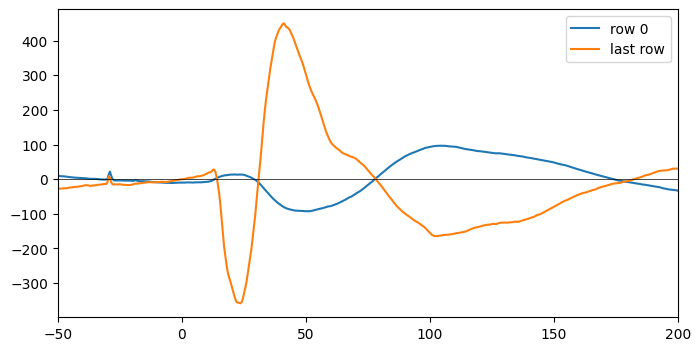

In [25]:
plt.figure(figsize=(8,4))
plt.plot(t, lfp[0], label='row 0')
plt.plot(t, lfp[-1], label='last row')
plt.axhline(0, color='k', lw=0.5)
plt.legend()
plt.xlim([-50, 200])
plt.show()

In [26]:
print("lfp row 0 is plotted at depth:", contact_labels[0])
print("lfp last row is plotted at depth:", contact_labels[-1])

lfp row 0 is plotted at depth: -125
lfp last row is plotted at depth: 2075
